# Laboratorio 5

- Pedro Pablo Guzmán Mayen

In [51]:
import pandas as pd
from scapy.all import *
import numpy as np
import matplotlib.pyplot as plt

## Parte 1

### Testeo de scapy

Primero, vamos a indicar que queremos capturar 10 paquetes

In [ ]:
p = sniff(filter='ip', count=10)

In [ ]:
for pkt in p:

    if IP in pkt:
        
        src_ip = pkt[IP].src
        dst_ip = pkt[IP].dst

        src_port = None
        dst_port = None

        if TCP in pkt:
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
        elif UDP in pkt:
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport

        print(f'{src_ip} -> {dst_ip} | {src_port} -> {dst_port}')

192.168.0.6 -> 224.0.0.251 | 5353 -> 5353
192.168.0.6 -> 192.168.0.12 | 8009 -> 64780
192.168.0.12 -> 192.168.0.6 | 64780 -> 8009
192.168.0.12 -> 20.42.65.85 | 65191 -> 443
192.168.0.12 -> 20.42.65.85 | 65191 -> 443
192.168.0.12 -> 20.42.65.85 | 65191 -> 443
20.42.65.85 -> 192.168.0.12 | 443 -> 65191
20.42.65.85 -> 192.168.0.12 | 443 -> 65191
20.42.65.85 -> 192.168.0.12 | 443 -> 65191
192.168.0.12 -> 20.42.65.85 | 65191 -> 443


### Detección de z-score

Ahora, vamos a cargar un archivo de tráfico de red más complejo y vamos a analizar mediante el z-score si hay anomalías. Primero convertimos en un df con la información relevante

In [24]:
packets = rdpcap('../resources/analisis_paquetes.pcap')
data = []

for pkt in packets:
    if IP in pkt:
        payload_len = 0

        if Raw in pkt:
            payload_len = len(pkt[Raw].load)

        row = {
            "src_ip": pkt[IP].src,
            "dst_ip": pkt[IP].dst,
            "protocol": None,
            "src_port": None,
            "dst_port": None,
            "length": len(pkt),
            "payload_len": payload_len
        }

        if TCP in pkt:
            row["protocol"] = "TCP"
            row["src_port"] = pkt[TCP].sport
            row["dst_port"] = pkt[TCP].dport
        elif UDP in pkt:
            row["protocol"] = "UDP"
            row["src_port"] = pkt[UDP].sport
            row["dst_port"] = pkt[UDP].dport
        elif ICMP in pkt:
            row["protocol"] = "ICMP"

        data.append(row)

df = pd.DataFrame(data)

Ahora que ya es un dataframe, vamos a analizar información relevante

In [35]:
df.head()

,src_ip,dst_ip,protocol,src_port,dst_port,length,payload_len
0,10.1.10.53,84.54.22.33,UDP,53,53,975,905
1,84.54.22.33,10.1.10.53,UDP,53,53,98,0
2,10.1.10.53,84.54.22.33,UDP,53,53,989,919
3,84.54.22.33,10.1.10.53,UDP,53,53,98,0
4,10.1.10.53,84.54.22.33,UDP,53,53,1026,956


1. Muestre cuál es la IP origen más frecuente

In [36]:
df['src_ip'].value_counts()

src_ip
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

La ip de origen más frecuente es la 10.1.10.53

2. Muestre cuál es la IP destino más frecuente

In [37]:
df['dst_ip'].value_counts()

dst_ip
10.1.10.53     31
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

La ip de destino más frecuente es 10.1.10.53, la misma que el inciso anterior

3. ¿A qué IPs se comunica la IP del inciso a?

In [28]:
df_frequent_src_ip = df[df['src_ip'] == '10.1.10.53']

df_frequent_src_ip['dst_ip'].value_counts()

dst_ip
84.54.22.33    29
75.75.75.75     2
Name: count, dtype: int64

La ip se comunica a la 84.54.22.33 de forma más frecuente pero también se comunica con la 75.75.75.75

4. ¿A qué puertos destino se comunica la IP del inciso a?

In [30]:
df_frequent_src_ip['dst_port'].value_counts()

dst_port
53    31
Name: count, dtype: int64

Se comunica con más frecuencia el puerto 53

5. ¿A qué puertos origen se comunica la IP del inciso b?

In [45]:
df_frequent_src_ip['src_port'].value_counts()

src_port
53       29
15812     1
23903     1
Name: count, dtype: int64

Casi tiene el puerto 53 como origen pero a veces usa otros como el 15812 o 23903

6. Indique el propósito de los puertos que más aparecen en los incisos d y e

El puerto 53 es el que usa DNS, los otros puertos no se usan de forma frecuente y son raros de utilizar. 

Ahora vamos a analizar el z-score de los paquetes capturados

In [47]:
mean = df["payload_len"].mean()
std = df["payload_len"].std()

df["z_score"] = (df["payload_len"] - mean) / std

In [48]:
df.head()

,src_ip,dst_ip,protocol,src_port,dst_port,length,payload_len,z_score
0,10.1.10.53,84.54.22.33,UDP,53,53,975,905,0.983906
1,84.54.22.33,10.1.10.53,UDP,53,53,98,0,-0.923532
2,10.1.10.53,84.54.22.33,UDP,53,53,989,919,1.013413
3,84.54.22.33,10.1.10.53,UDP,53,53,98,0,-0.923532
4,10.1.10.53,84.54.22.33,UDP,53,53,1026,956,1.091397


Ya con el z-score, vamos a ver si hay paquetes anómalos, que tengan un z-score mayor a 2, eso incluye a los que tienen el z-score mayor a 3

In [50]:
df_anomalies_2 = df[df['z_score'] > 2.0]
df_anomalies_2.shape

(0, 8)

No encontramos paquetes anómalos, vamos a ver la distribución del payload.  

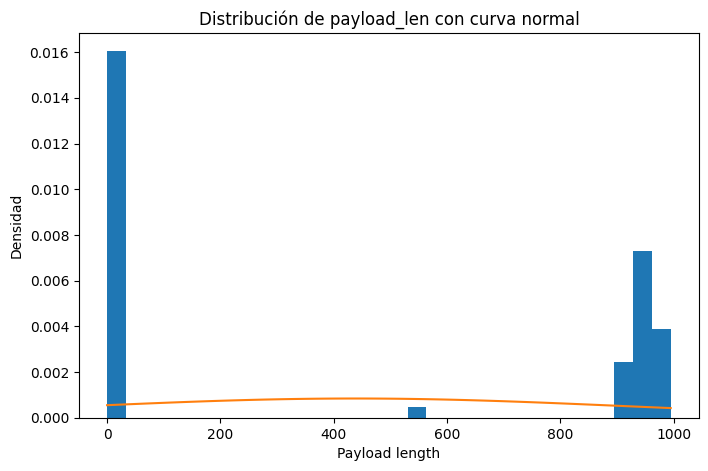

In [54]:
plt.figure(figsize=(8,5))

count, bins, _ = plt.hist(df["payload_len"], bins=30, density=True)

mean = df["payload_len"].mean()
std = df["payload_len"].std()

x = np.linspace(min(bins), max(bins), 100)
y = (1/(std * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean)/std)**2)

plt.plot(x, y)

plt.title("Distribución de payload_len con curva normal")
plt.xlabel("Payload length")
plt.ylabel("Densidad")

plt.show()